In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import os
import glob
import json
import re
import random
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import math
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import word_tokenize
from collections import Counter

In [2]:
df_combined_no_duplicates = pd.read_csv('ai_ edu_keywords_all.csv', dtype=str)

# 1) Perform Sentiment Analysis using VADER
analyzer = SentimentIntensityAnalyzer()

# 2) Apply sentiment analysis and get the compound score for each post
df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# 3) Print the first few rows of the updated DataFrame
df_combined_no_duplicates[['text', 'sentiment_score']]

#df_combined_no_duplicates.to_csv('sentiment_analysis_output_all.csv', index=False)
df_combined_no_duplicates

,date,text,sentiment_score
0,2023-12-13,counterpoint: please keep relying on AI for le...,0.6831
1,2023-12-04,"for my university's ""committee on socially res...",0.6369
2,2024-01-03,AI bros getting heated about plagiarism is pre...,0.7269
3,2024-02-26,A college vending machine showed an error mess...,-0.3248
4,2023-10-06,Gen AI evangelists have really dropped all pre...,0.7096
...,...,...,...
116226,2025-03-26,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...,0.0000
116227,2025-03-26,This makes a compelling argument: AI might be ...,-0.5801
116228,2025-03-26,"I don’t use AI-generated images for my talks, ...",-0.8867
116229,2025-03-26,AI won't eliminate teachers. We're essentially...,-0.1426


In [20]:
df_combined_no_duplicates.iloc[-1]["text"]
#???

"Zimmerman is coming off as deeply in the pockets of big business. Can't believe that the moneygrabbing construction companies, so reluctant to build affordable housing, ALSO are crying that banning AI algorithmic rent fixing would hurt business. If you can't do business without cheating people...."

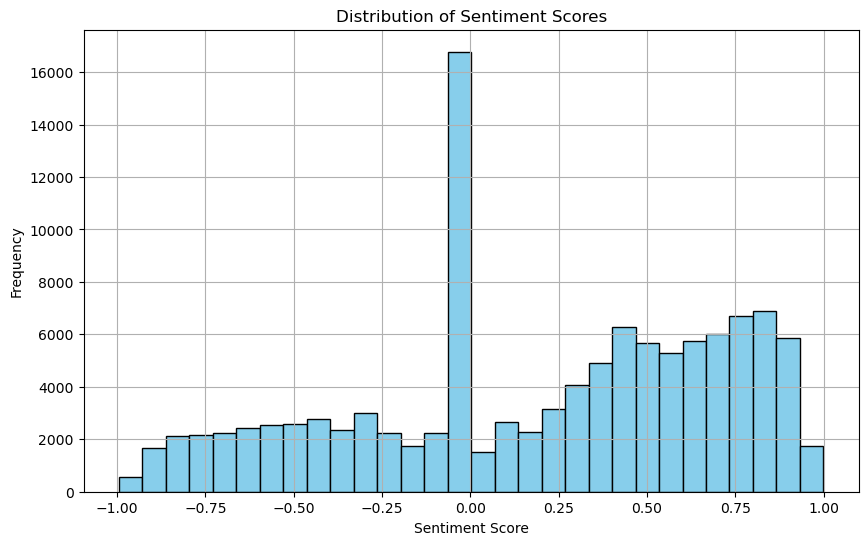

In [23]:
# Plot the distribution of sentiment scores
plt.figure(figsize=(10, 6))
plt.hist(df_combined_no_duplicates['sentiment_score'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

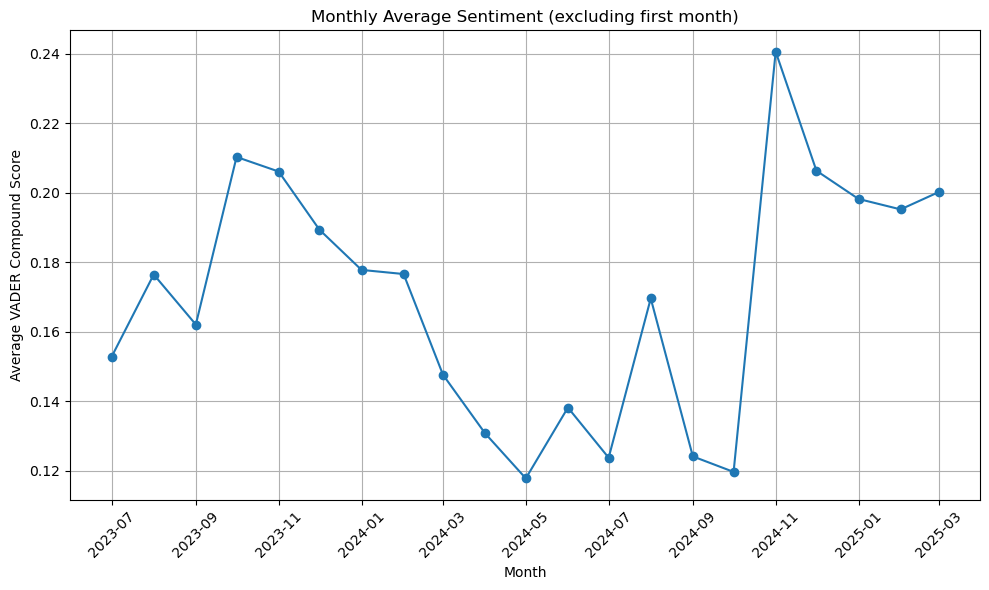

In [5]:
# Ensure VADER lexicon is available
nltk.download('vader_lexicon', quiet=True)

# 1) Concatenate sampled and df1 into final_df
final_df = df_combined_no_duplicates

# 2) Prepare data
final_df['date'] = pd.to_datetime(final_df['date'], errors='coerce')
final_df.dropna(subset=['date', 'text'], inplace=True)

# 3) Compute sentiment scores for each text
analyzer = SentimentIntensityAnalyzer()
final_df['sentiment_score'] = final_df['text'].apply(lambda txt: analyzer.polarity_scores(str(txt))['compound'])

# 4) Exclude the first month
final_df['year_month'] = final_df['date'].dt.to_period('M')
first_month = final_df['year_month'].min()
df_filtered = final_df[final_df['year_month'] != first_month]

# 5) Calculate monthly average sentiment
monthly_sent = df_filtered.groupby('year_month')['sentiment_score'].mean().reset_index()
monthly_sent['year_month'] = monthly_sent['year_month'].dt.to_timestamp()

# 6) Plot
plt.figure(figsize=(10, 6))
plt.plot(monthly_sent['year_month'], monthly_sent['sentiment_score'], marker='o')
plt.title('Monthly Average Sentiment (excluding first month)')
plt.xlabel('Month')
plt.ylabel('Average VADER Compound Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

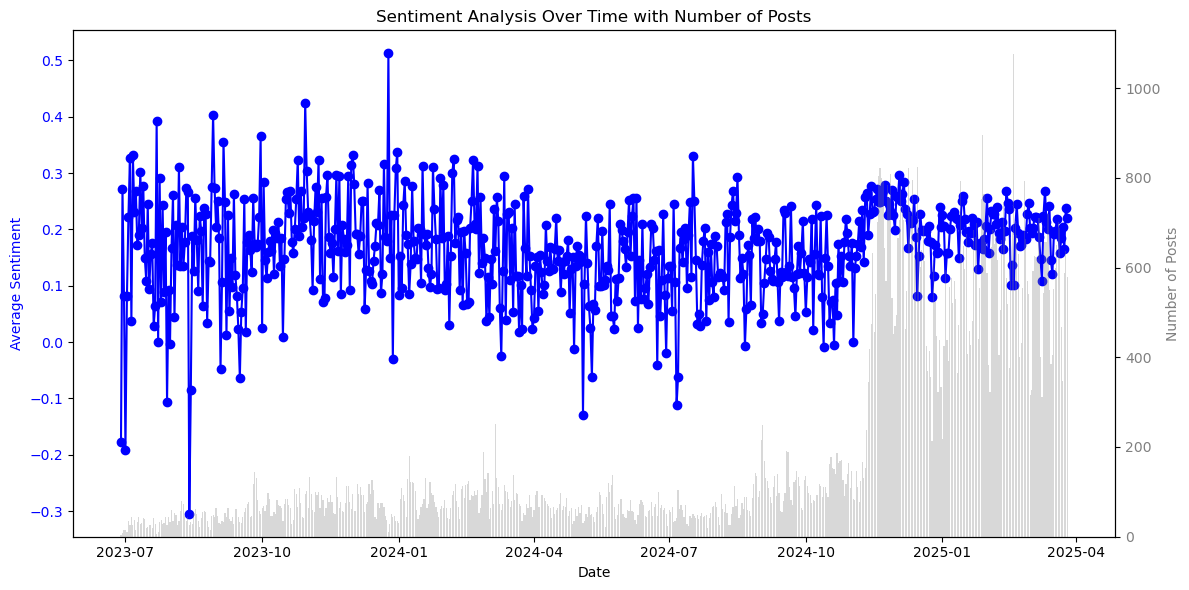

In [ ]:
# Ensure the 'date' column is in datetime format
df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')

# Apply sentiment analysis and get the compound score for each post
df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# 3) Aggregate sentiments by date and count the number of posts per date
sentiment_by_date = df_combined_no_duplicates.groupby(df_combined_no_duplicates['date'].dt.date).agg(
    sentiment_mean=('sentiment_score', 'mean'),
    post_count=('sentiment_score', 'count')
).reset_index()

# 4) Plot the sentiment scores along with post counts
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot sentiment scores (average per day)
ax1.plot(sentiment_by_date['date'], sentiment_by_date['sentiment_mean'], color='b', label='Average Sentiment', marker='o')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Sentiment', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot post counts (on a secondary axis)
ax2 = ax1.twinx()  
ax2.bar(sentiment_by_date['date'], sentiment_by_date['post_count'], color='gray', alpha=0.3, label='Number of Posts')
ax2.set_ylabel('Number of Posts', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Title and layout
plt.title('Sentiment Analysis Over Time with Number of Posts')
fig.tight_layout()  # Adjust layout to prevent clipping
plt.xticks(rotation=45)
plt.show()


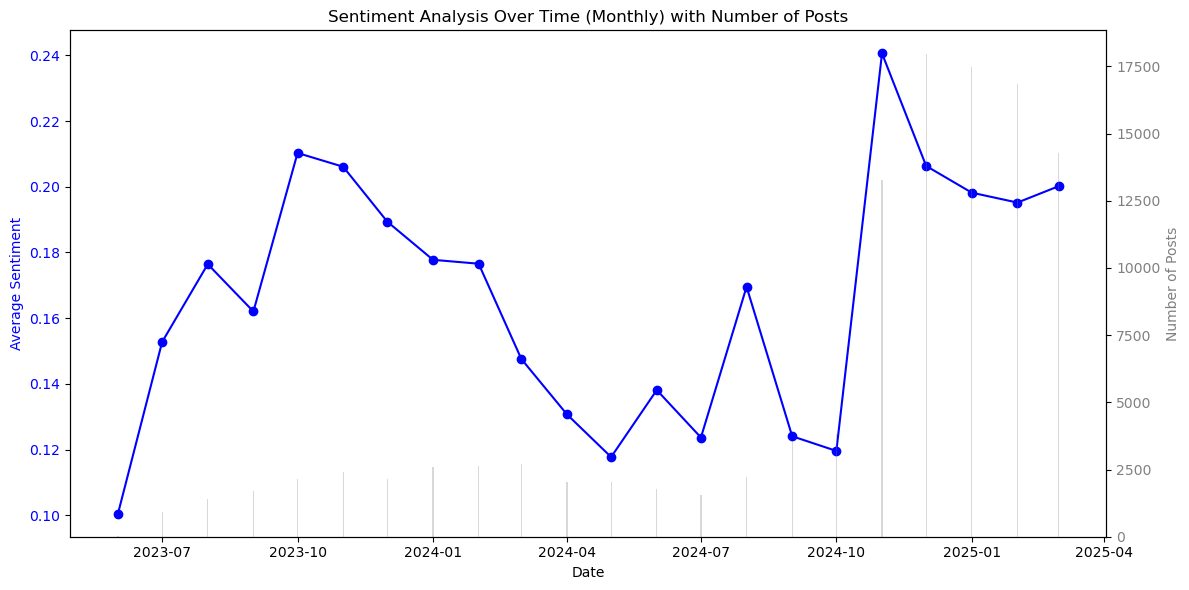

In [8]:
# 3) Aggregate sentiments by month and year, and count the number of posts per month
sentiment_by_month = df_combined_no_duplicates.groupby(df_combined_no_duplicates['date'].dt.to_period('M')).agg(
    sentiment_mean=('sentiment_score', 'mean'),
    post_count=('sentiment_score', 'count')
).reset_index()

# Convert the Period to a datetime object for plotting
sentiment_by_month['date'] = sentiment_by_month['date'].dt.to_timestamp()

# 4) Plot the sentiment scores along with post counts
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot sentiment scores (average per month)
ax1.plot(sentiment_by_month['date'], sentiment_by_month['sentiment_mean'], color='b', label='Average Sentiment', marker='o')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Sentiment', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot post counts (on a secondary axis)
ax2 = ax1.twinx()  
ax2.bar(sentiment_by_month['date'], sentiment_by_month['post_count'], color='gray', alpha=0.3, label='Number of Posts')
ax2.set_ylabel('Number of Posts', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Title and layout
plt.title('Sentiment Analysis Over Time (Monthly) with Number of Posts')
fig.tight_layout()  # Adjust layout to prevent clipping
plt.xticks(rotation=45)
plt.show()

In [11]:
import pandas as pd
import numpy as np

# Assuming df_combined_no_duplicates is already loaded and contains 'date' and 'sentiment_score' columns

# 1) Ensure 'date' column is in datetime format
df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')

# 2) Aggregate sentiment scores by date and calculate the mean
sentiment_by_day = df_combined_no_duplicates.groupby(df_combined_no_duplicates['date'].dt.date).agg(
    sentiment_mean=('sentiment_score', 'mean'),
    post_count=('sentiment_score', 'count')
).reset_index()

# 3) Sort by sentiment mean and find the days with the lowest and highest average sentiment
sentiment_by_day_sorted = sentiment_by_day.sort_values(by='sentiment_mean')

# Get the days with the lowest and highest sentiment
lowest_sentiment_days = sentiment_by_day_sorted.head(int(len(sentiment_by_day_sorted) / 2))
highest_sentiment_days = sentiment_by_day_sorted.tail(int(len(sentiment_by_day_sorted) / 2))

# 4) Filter the original DataFrame for those days
lowest_sentiment_dates = lowest_sentiment_days['date']
highest_sentiment_dates = highest_sentiment_days['date']

df_lowest_sentiment = df_combined_no_duplicates[df_combined_no_duplicates['date'].dt.date.isin(lowest_sentiment_dates)]
df_highest_sentiment = df_combined_no_duplicates[df_combined_no_duplicates['date'].dt.date.isin(highest_sentiment_dates)]

# 5) Take 50% of samples from each of these DataFrames
df_lowest_sample = df_lowest_sentiment.sample(frac=0.5, random_state=42)
df_highest_sample = df_highest_sentiment.sample(frac=0.5, random_state=42)

# 6) Concatenate the selected samples
df_combined_selected = pd.concat([df_lowest_sample, df_highest_sample])

# Show the final DataFrame
print(f"Number of selected samples: {df_combined_selected.shape[0]}")
print(df_combined_selected.head())


Number of selected samples: 57700
             date                                               text  \
80690  2025-01-25  .@3blue1brown says that his videos are edutain...   
34964  2024-10-24  partially inspired by my struggles at finding ...   
59845  2024-12-16  Any chance I could see that assignment? I'm sk...   
13168  2023-08-15  Unwrap the day's happenings with Newslit Daily...   
113043 2025-03-21  My few academic papers are in the LibGen colle...   

        sentiment_score year_month         day  
80690           -0.6124    2025-01  2025-01-25  
34964            0.3939    2024-10  2024-10-24  
59845            0.8462    2024-12  2024-12-16  
13168            0.7269    2023-08  2023-08-15  
113043          -0.5709    2025-03  2025-03-21  


In [14]:
lowest_sentiment_days

,date,sentiment_mean,post_count
46,2023-08-13,-0.320919,27
0,2023-06-28,-0.224525,4
31,2023-07-29,-0.189763,27
3,2023-07-01,-0.179031,16
311,2024-05-04,-0.131629,31
...,...,...,...
170,2023-12-15,0.182775,105
605,2025-02-22,0.183380,401
380,2024-07-12,0.183633,70
225,2024-02-08,0.183690,118


In [15]:
highest_sentiment_days

,date,sentiment_mean,post_count
128,2023-11-03,0.184948,96
74,2023-09-10,0.185063,35
220,2024-02-03,0.185076,42
495,2024-11-04,0.185307,146
545,2024-12-24,0.185374,355
...,...,...,...
62,2023-08-29,0.394635,48
69,2023-09-05,0.398367,33
94,2023-09-30,0.400661,51
124,2023-10-30,0.401692,95


In [16]:
import pandas as pd
import os

# Assuming df_combined_no_duplicates is already loaded and has a 'date' and 'text' column

# Convert 'date' to datetime format
df_combined_no_duplicates['date'] = pd.to_datetime(df_combined_no_duplicates['date'], errors='coerce')

# Define the target dates
lowest_group = ['2023-08-13', '2023-06-28', '2023-07-29']
highest_group = ['2023-12-25', '2023-10-30', '2023-09-30']

# Convert these to datetime objects
dates_lowest_group= pd.to_datetime(lowest_group)
dates_highest_group = pd.to_datetime(highest_group)

# Filter the DataFrame for each group based on the 'date' column
df_group_1 = df_combined_no_duplicates[df_combined_no_duplicates['date'].isin(dates_lowest_group)]
df_group_2 = df_combined_no_duplicates[df_combined_no_duplicates['date'].isin(dates_highest_group)]

# Create directories to save the files
folder_group_1 = 'lowest_group_folder'
folder_group_2 = 'highest_group_folder'

# Create folders if they don't exist
os.makedirs(folder_group_1, exist_ok=True)
os.makedirs(folder_group_2, exist_ok=True)

# Function to split DataFrame into chunks and save them
def save_csv_in_chunks(df, folder, group_name):
    chunk_size = len(df) // 3  # Split into 3 CSV files
    for i in range(3):
        start_idx = i * chunk_size
        end_idx = (i + 1) * chunk_size if i < 2 else len(df)  # Ensure last chunk gets remaining data
        chunk = df.iloc[start_idx:end_idx]
        file_name = f"{group_name}_part_{i+1}.csv"
        file_path = os.path.join(folder, file_name)
        chunk.to_csv(file_path, index=False)
        print(f"Saved {file_name} in {folder}")

# Save group_1 data in 3 CSV files
save_csv_in_chunks(df_group_1, folder_group_1, "group_1")

# Save group_2 data in 3 CSV files
save_csv_in_chunks(df_group_2, folder_group_2, "group_2")

Saved group_1_part_1.csv in lowest_group_folder
Saved group_1_part_2.csv in lowest_group_folder
Saved group_1_part_3.csv in lowest_group_folder
Saved group_2_part_1.csv in highest_group_folder
Saved group_2_part_2.csv in highest_group_folder
Saved group_2_part_3.csv in highest_group_folder


C:\Users\kiara\AppData\Local\Temp\ipykernel_3196\3070095166.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_positive['cleaned_text'] = top_positive['text'].apply(clean_text)
C:\Users\kiara\AppData\Local\Temp\ipykernel_3196\3070095166.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_negative['cleaned_text'] = top_negative['text'].apply(clean_text)


Top 10 Most Common Positive Sentiment Words:
ai: 48267
research: 13668
education: 6729
like: 6366
use: 5645
new: 4107
just: 4105
im: 4083
students: 3980
learning: 3319
test: 3309
work: 3288
teaching: 3186
using: 3075
good: 3005
help: 2857
intelligence: 2851
student: 2751
people: 2717
tools: 2654

Top 10 Most Common Negative Sentiment Words:
ai: 17632
research: 3645
just: 2395
use: 2241
people: 1914
education: 1833
dont: 1596
im: 1587
using: 1550
plagiarism: 1518
students: 1487
test: 1320
like: 1320
work: 1291
cheating: 1190
bad: 1134
think: 1101
student: 1054
teach: 964
teaching: 950


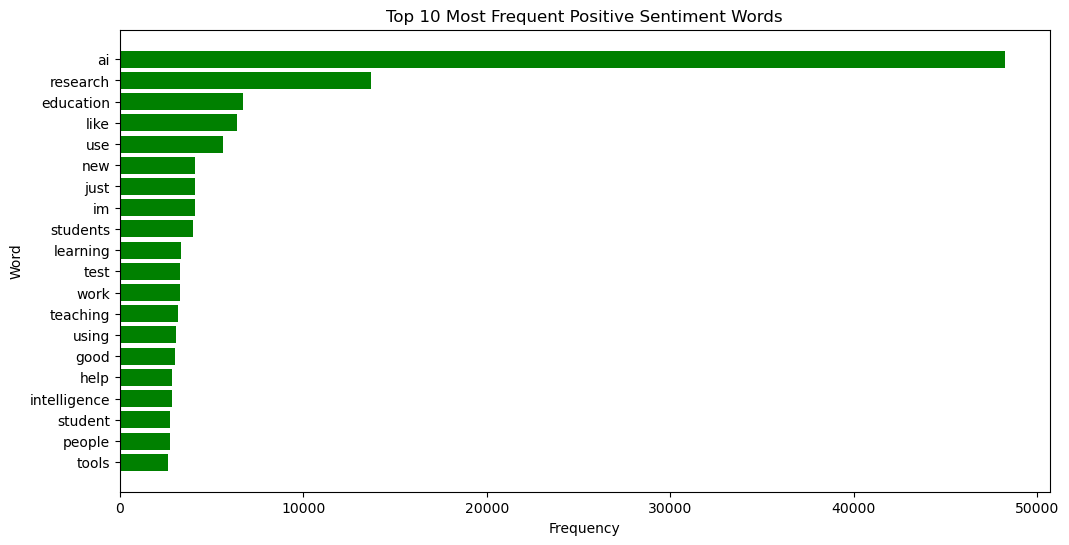

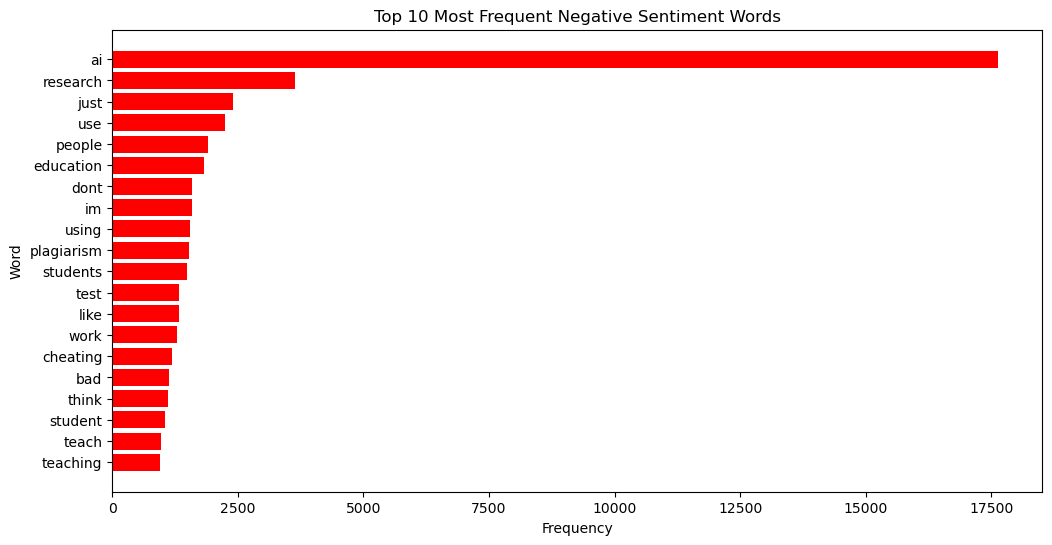

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

# Assuming df_combined_no_duplicates is already loaded

# 1) Perform Sentiment Analysis using VADER
analyzer = SentimentIntensityAnalyzer()

# Get compound sentiment score for each post
df_combined_no_duplicates['sentiment_score'] = df_combined_no_duplicates['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# 2) Filter out the top positive and negative sentiment posts
top_positive = df_combined_no_duplicates[df_combined_no_duplicates['sentiment_score'] > 0.5]  # Positive sentiment threshold
top_negative = df_combined_no_duplicates[df_combined_no_duplicates['sentiment_score'] < -0.5]  # Negative sentiment threshold

# 3) Tokenize the posts and remove non-alphanumeric characters and stop words
def clean_text(text):
    # Remove special characters, links, etc.
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # Tokenize and remove stop words
    words = text.split()
    return [word for word in words if word not in ENGLISH_STOP_WORDS]

top_positive['cleaned_text'] = top_positive['text'].apply(clean_text)
top_negative['cleaned_text'] = top_negative['text'].apply(clean_text)

# 4) Tokenize and count word frequencies
positive_words = [word for post in top_positive['cleaned_text'] for word in post]
negative_words = [word for post in top_negative['cleaned_text'] for word in post]

positive_word_counts = Counter(positive_words)
negative_word_counts = Counter(negative_words)

# 5) Get the 10 most common words for each sentiment
top_positive_words = positive_word_counts.most_common(20)
top_negative_words = negative_word_counts.most_common(20)

# 6) Print the most frequent words
print("Top 20 Most Common Positive Sentiment Words:")
for word, count in top_positive_words:
    print(f"{word}: {count}")

print("\nTop 20 Most Common Negative Sentiment Words:")
for word, count in top_negative_words:
    print(f"{word}: {count}")

# 7) Optional: Plot the most frequent words for positive and negative sentiments
# Plotting positive sentiment words
plt.figure(figsize=(12, 6))
positive_words, positive_counts = zip(*top_positive_words)
plt.barh(positive_words, positive_counts, color='green')
plt.title('Top 20 Most Frequent Positive Sentiment Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.gca().invert_yaxis()  # Invert y-axis to display the most common words at the top
plt.show()

# Plotting negative sentiment words
plt.figure(figsize=(12, 6))
negative_words, negative_counts = zip(*top_negative_words)
plt.barh(negative_words, negative_counts, color='red')
plt.title('Top 10 Most Frequent Negative Sentiment Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.gca().invert_yaxis()  # Invert y-axis to display the most common words at the top
plt.show()


2/7 to 9/7
Also AI Keywords Added as a txt file 

In [8]:
import pandas as pd

# Assuming df_combined_no_duplicates already exists

# 1. Sort the DataFrame based on 'sentiment_score' for positive and negative posts
df_sorted = df_combined_no_duplicates.sort_values(by="sentiment_score", ascending=False)

# 2. Get the 100 most positive sentiment posts (highest sentiment score)
df_most_positive = df_sorted.head(100)

# 3. Get the 100 most negative sentiment posts (lowest sentiment score)
df_most_negative = df_sorted.tail(100)

# 4. Optionally, display the results or save them as new CSV files
print("100 Most Positive Sentiment Posts:")
print(df_most_positive[['date', 'text', 'sentiment_score']])

print("100 Most Negative Sentiment Posts:")
print(df_most_negative[['date', 'text', 'sentiment_score']])

# Optionally save to CSV
df_most_positive.to_csv("most_positive_posts.csv", index=False)
df_most_negative.to_csv("most_negative_posts.csv", index=False)


100 Most Positive Sentiment Posts:
              date                                               text  \
30507   2024-09-16  🤣🤣🤣🤣🤣🤣🤣  dormi 50 minutos  pensei, vou faltar ...   
85379   2025-02-02  How is your first post on your student film’s ...   
77876   2025-01-21  Smart Humor For Today:  AI = ELON MUSK  Astrid...   
64158   2024-12-24  Share the love and find the perfect gift this ...   
66483   2024-12-29  Funny thing about AI, they don't teach you how...   
...            ...                                                ...   
100711  2025-02-26  Really interesting situation has returned wher...   
33066   2024-10-09  We live our dark academia magic school dreams ...   
70795   2025-01-08  Perhaps a bit of an unpopular opinion here on ...   
44675   2024-11-23  Hey #EduSky! Let’s get to know each other 😊.  ...   
72917   2025-01-12  While working on my next book one of the very ...   

        sentiment_score  
30507            0.9994  
85379            0.9947  
77876     

In [ ]:
import math
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Assuming you have the 'df_combined_no_duplicates' DataFrame with 'date', 'text', 'sentiment_score' columns

# 1. Define positive and negative thresholds for sentiment
positive_threshold = 0.5  # You can adjust this as needed
negative_threshold = -0.5  # You can adjust this as needed

# 2. Split the dataset into positive and negative posts based on sentiment score
positive_posts = df_combined_no_duplicates[df_combined_no_duplicates['sentiment_score'] > positive_threshold]['text']
negative_posts = df_combined_no_duplicates[df_combined_no_duplicates['sentiment_score'] < negative_threshold]['text']

# 3. Tokenize and count word frequencies in positive and negative posts
vectorizer = CountVectorizer(stop_words='english', lowercase=True)
positive_word_counts = vectorizer.fit_transform(positive_posts).toarray().sum(axis=0)
negative_word_counts = vectorizer.transform(negative_posts).toarray().sum(axis=0)

# 4. Calculate the total number of words in each set of posts
positive_total_words = positive_word_counts.sum()
negative_total_words = negative_word_counts.sum()

# 5. Compute word probabilities for positive and negative posts
positive_word_probabilities = positive_word_counts / positive_total_words
negative_word_probabilities = negative_word_counts / negative_total_words

# 6. Calculate polarity for each word
vocabulary = vectorizer.get_feature_names_out()

word_polarities = {}
for i, word in enumerate(vocabulary):
    pr_pos = positive_word_probabilities[i]
    pr_neg = negative_word_probabilities[i]
    
    if pr_neg == 0:  # To avoid division by zero, add a small constant if needed
        pr_neg = 1e-10
    
    # Apply the polarity formula
    polarity = math.log(pr_pos / pr_neg)
    word_polarities[word] = polarity

# 7. Sort words by their polarity (most polar words first)
sorted_word_polarities = sorted(word_polarities.items(), key=lambda item: item[1], reverse=True)

# 8. Display the most polar words
top_polar_words = sorted_word_polarities[:20]  # Get top 20 polar words
print("Most Polar Words:")
for word, polarity in top_polar_words:
    print(f"Word: {word}, Polarity: {polarity:.4f}")

Most Polar Words:
Word: museum, Polarity: 14.4802
Word: masterpiece, Polarity: 14.1853
Word: sdxl, Polarity: 14.1706
Word: 1girl, Polarity: 14.1328
Word: controlaltachieve, Polarity: 14.1173
Word: delighted, Polarity: 13.9748
Word: womenartists, Polarity: 13.9748
Word: zen, Polarity: 13.9097
Word: congratulations, Polarity: 13.9000
Word: unlock, Polarity: 13.9000
Word: absurdres, Polarity: 13.8086
Word: rijksmuseum, Polarity: 13.8086
Word: magicschoolai, Polarity: 13.6220
Word: postimpress, Polarity: 13.4700
Word: hci, Polarity: 13.4397
Word: outstanding, Polarity: 13.3924
Word: classtechtips, Polarity: 13.3596
Word: enhances, Polarity: 13.3596
Word: axiomzen, Polarity: 13.2906
Word: brisk, Polarity: 13.2906


In [10]:
!pip install gensim

   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ----- ---------------------------------- 2.1/15.5 MB 16.8 MB/s eta 0:00:01
   ------------------------ --------------- 9.4/15.5 MB 28.0 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.5 MB 30.4 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 27.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.1
    Uninstalling numpy-2.3.1:
      Successfully uninstalled numpy-2.3.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [12]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel

# Download NLTK stopwords if you haven't already
nltk.download('stopwords')

# Assuming you have a dataframe named df_combined_no_duplicates
# df = pd.read_csv("your_file.csv")  # Uncomment if the df is not already loaded

# 1. Preprocess the text
def preprocess_text(text):
    # Tokenize and remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = text.lower().split()  # Tokenizing and converting text to lower case
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return filtered_tokens

# Apply the preprocessing function
df_combined_no_duplicates['processed_text'] = df_combined_no_duplicates['text'].apply(preprocess_text)

# 2. Create a dictionary and a corpus
# Create a dictionary from the processed text
dictionary = corpora.Dictionary(df_combined_no_duplicates['processed_text'])

# Create a corpus (bag of words)
corpus = [dictionary.doc2bow(text) for text in df_combined_no_duplicates['processed_text']]

# 3. Build the LDA model
lda_model = LdaModel(corpus, num_topics=5, id2word=dictionary, passes=15)

# 4. Display the topics
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic #{idx + 1}: {topic}")

# 5. Assign topics to each document
topics = lda_model.get_document_topics(corpus)

# 6. Add the dominant topic for each post to the dataframe
df_combined_no_duplicates['dominant_topic'] = [max(doc, key=lambda item: item[1])[0] for doc in topics]

# 7. Show the resulting dataframe with topics
print(df_combined_no_duplicates[['text', 'dominant_topic']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kiara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic #1: 0.067*"ai" + 0.014*"use" + 0.013*"like" + 0.011*"people" + 0.011*"teach" + 0.010*"students" + 0.009*"think" + 0.008*"get" + 0.008*"using" + 0.007*"teaching"
Topic #2: 0.023*"test" + 0.010*"video" + 0.009*"image" + 0.008*"trump" + 0.007*"ai" + 0.006*"generated" + 0.006*"cancer" + 0.005*"prompt" + 0.005*"quality" + 0.005*"blog"
Topic #3: 0.066*"ai" + 0.027*"research" + 0.014*"test" + 0.012*"use" + 0.008*"used" + 0.007*"using" + 0.007*"like" + 0.006*"academic" + 0.006*"one" + 0.005*"human"
Topic #4: 0.064*"ai" + 0.033*"research" + 0.013*"new" + 0.008*"education" + 0.007*"artificial" + 0.007*"learning" + 0.007*"intelligence" + 0.006*"data" + 0.006*"us" + 0.005*"tools"
Topic #5: 0.016*"education" + 0.010*"tech" + 0.008*"schools" + 0.007*"public" + 0.007*"government" + 0.005*"vision" + 0.005*"risk" + 0.005*"new" + 0.005*"us" + 0.005*"pro"
                                                text  dominant_topic
0  counterpoint: please keep relying on AI for le...               2
1  for 

In [13]:
df_combined_no_duplicates

,date,text,sentiment_score,processed_text,dominant_topic
0,2023-12-13,counterpoint: please keep relying on AI for le...,0.6831,"[please, keep, relying, ai, legal, research, e...",2
1,2023-12-04,"for my university's ""committee on socially res...",0.6369,"[socially, responsible, oversight, body, ensur...",4
2,2024-01-03,AI bros getting heated about plagiarism is pre...,0.7269,"[ai, bros, getting, heated, plagiarism, pretty...",0
3,2024-02-26,A college vending machine showed an error mess...,-0.3248,"[college, vending, machine, showed, error, mes...",2
4,2023-10-06,Gen AI evangelists have really dropped all pre...,0.7096,"[gen, ai, evangelists, really, dropped, preten...",0
...,...,...,...,...,...
116226,2025-03-26,#scribaland QUAND LES CHAUVES PRENNENT LE POUV...,0.0000,"[quand, les, chauves, prennent, le, pouvoir, l...",0
116227,2025-03-26,This makes a compelling argument: AI might be ...,-0.5801,"[makes, compelling, ai, might, leveler, profs,...",0
116228,2025-03-26,"I don’t use AI-generated images for my talks, ...",-0.8867,"[use, images, teaching, anything, lazy, want, ...",0
116229,2025-03-26,AI won't eliminate teachers. We're essentially...,-0.1426,"[ai, eliminate, essentially, childcare, ai, lo...",0


In [14]:
df_combined_no_duplicates["dominant_topic"].unique()

array([2, 4, 0, 3, 1], dtype=int64)